<a href="https://colab.research.google.com/github/Theres-jose/Internship_2026/blob/main/CNN_VGG_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import required libraries**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

**Load and Sample Fashion MNIST dataset**

In [ ]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.fashion_mnist.load_data()

In [ ]:
x_train,y_train=x_train[:100],y_train[:100]
x_test,y_test=x_test[:100],y_test[:100]

**Resize images to 224*224**

In [ ]:
x_train=tf.image.resize(x_train,(224,224))
x_test=tf.image.resize(x_test,(224,224))

**Normalization**

In [ ]:
x_train=x_train/255.0
x_test=x_test/255.0

**One hot encoding**

In [ ]:
# Re-load the original data to ensure y_train and y_test are not None
(_, y_train_full), (_, y_test_full) = tf.keras.datasets.fashion_mnist.load_data()

# Sample to 100 as per previous steps in the notebook
y_train = y_train_full[:100]
y_test = y_test_full[:100]

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

**Load pretrained VGG16 without top layers**

In [ ]:
base_model=VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Freeze base model layers(Feature extraction)**

In [ ]:
for layer in base_model.layers:
  layer.trainable=False

**Add custom top layers**

In [ ]:
x=base_model.output
x=Flatten()(x)
x=Dense(256,activation="relu")(x)
x=Dropout(0.5)(x)
predictions=Dense(10,activation="softmax")(x)

**Create the final model**

In [ ]:
model=Model(inputs=base_model.input,outputs=predictions)

**Compile the model(feature extraction Phase)**

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4),loss='categorical_crossentropy',metrics=['accuracy'])

**Train the model(only top layers)**

In [ ]:

(raw_x_train, raw_y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
x_train_processed = raw_x_train[:100] # Slice to 100 samples
y_train_processed = raw_y_train[:100] # Slice to 100 samples


x_train_processed = tf.cast(x_train_processed, tf.float32) / 255.0


x_train_processed = tf.expand_dims(x_train_processed, axis=-1) # (100, 28, 28, 1)


x_train_processed = tf.image.resize(x_train_processed, (224, 224)) # (100, 224, 224, 1)


x_train_processed = tf.image.grayscale_to_rgb(x_train_processed) # (100, 224, 224, 3)


y_train_processed = to_categorical(y_train_processed)
y_train_processed = tf.cast(y_train_processed, tf.float32)

print(f"Shape of x_train_processed before model.fit: {x_train_processed.shape}")
print(f"Shape of y_train_processed before model.fit: {y_train_processed.shape}")


history=model.fit(x_train_processed.numpy(), y_train_processed.numpy(), epochs=5, batch_size=32, validation_split=0.2)

Shape of x_train_processed before model.fit: (100, 224, 224, 3)
Shape of y_train_processed before model.fit: (100, 10)
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 27s/step - accuracy: 0.1375 - loss: 2.5053 - val_accuracy: 0.2500 - val_loss: 1.9478
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 27s/step - accuracy: 0.3500 - loss: 1.8442 - val_accuracy: 0.2000 - val_loss: 1.6431
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 27s/step - accuracy: 0.5000 - loss: 1.2937 - val_accuracy: 0.6500 - val_loss: 1.1260
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 27s/step - accuracy: 0.7000 - loss: 0.8565 - val_accuracy: 0.8000 - val_loss: 0.7845
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 26s/step - accuracy: 0.8500 - loss: 0.5296 - val_accuracy: 0.8000 - val_loss: 0.6349


**Fine-tune some convolutional layer**

In [ ]:
for layer in base_model.layers[-4:]:
  layer.trainable=True

**Compile Again(After unfreezing)**

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-5),loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# Re-load and process x_train and y_train for fine-tuning to ensure correct cardinality and shape
(raw_x_train, raw_y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
x_train_fine = raw_x_train[:100] # Slice to 100 samples
y_train_fine = raw_y_train[:100] # Slice to 100 samples

# Convert to float32 and normalize x_train
x_train_fine = tf.cast(x_train_fine, tf.float32) / 255.0

# Add channel dimension before resizing to correctly handle batch of grayscale images
x_train_fine = tf.expand_dims(x_train_fine, axis=-1) # (100, 28, 28, 1)

# Explicitly resize images to 224x224
x_train_fine = tf.image.resize(x_train_fine, (224, 224)) # (100, 224, 224, 1)

# Now convert to 3 channels for VGG16
x_train_fine = tf.image.grayscale_to_rgb(x_train_fine) # (100, 224, 224, 3)

# One-hot encode y_train and cast to float32
y_train_fine = to_categorical(y_train_fine)
y_train_fine = tf.cast(y_train_fine, tf.float32)

print(f"Shape of x_train_fine before model.fit: {x_train_fine.shape}")
print(f"Shape of y_train_fine before model.fit: {y_train_fine.shape}")

# Convert tensors to NumPy arrays to ensure concrete shapes for model.fit
history_fine=model.fit(x_train_fine.numpy(), y_train_fine.numpy(), epochs=5, batch_size=32,validation_split=0.2)

Shape of x_train_fine before model.fit: (100, 224, 224, 3)
Shape of y_train_fine before model.fit: (100, 10)
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 77s 26s/step - accuracy: 0.7500 - loss: 0.9368 - val_accuracy: 0.6500 - val_loss: 1.1060
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 72s 22s/step - accuracy: 0.7125 - loss: 0.8979 - val_accuracy: 0.6500 - val_loss: 1.0703
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 26s/step - accuracy: 0.7500 - loss: 0.8663 - val_accuracy: 0.6000 - val_loss: 1.0229
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 27s/step - accuracy: 0.7250 - loss: 0.8082 - val_accuracy: 0.6000 - val_loss: 0.9742
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 26s/step - accuracy: 0.7625 - loss: 0.7241 - val_accuracy: 0.6000 - val_loss: 0.9198


### Re-creating the model for evaluation context

In [ ]:
# Load pretrained VGG16 without top layers
base_model=VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))

In [ ]:
# Freeze base model layers(Feature extraction)
for layer in base_model.layers:
  layer.trainable=False

In [ ]:
# Add custom top layers
x=base_model.output
x=Flatten()(x)
x=Dense(256,activation="relu")(x)
x=Dropout(0.5)(x)
predictions=Dense(10,activation="softmax")(x)

In [ ]:
# Create the final model
model=Model(inputs=base_model.input,outputs=predictions)

In [ ]:
# Compile the model(feature extraction Phase)
model.compile(optimizer=Adam(learning_rate=1e-4),loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# Fine-tune some convolutional layer
for layer in base_model.layers[-4:]:
  layer.trainable=True

In [ ]:
# Compile Again(After unfreezing)
model.compile(optimizer=Adam(learning_rate=1e-5),loss='categorical_crossentropy',metrics=['accuracy'])

**Evaluate on test set**

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
# Re-load and process x_test and y_test to ensure correct cardinality and shape within this cell
(raw_x_test, raw_y_test), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
x_test_processed = raw_x_test[:100] # Slice to 100 samples
y_test_processed = raw_y_test[:100] # Slice to 100 samples

# Convert to float32 and normalize x_test
x_test_processed = tf.cast(x_test_processed, tf.float32) / 255.0

# Add channel dimension before resizing to correctly handle batch of grayscale images
x_test_processed = tf.expand_dims(x_test_processed, axis=-1) # (100, 28, 28, 1)

# Explicitly resize images to 224x224
x_test_processed = tf.image.resize(x_test_processed, (224, 224)) # (100, 224, 224, 1)

# Now convert to 3 channels for VGG16
x_test_processed = tf.image.grayscale_to_rgb(x_test_processed) # (100, 224, 224, 3)

# One-hot encode y_test and cast to float32
y_test_processed = to_categorical(y_test_processed)
y_test_processed = tf.cast(y_test_processed, tf.float32)

print(f"Shape of x_test_processed before model.evaluate: {x_test_processed.shape}")
print(f"Shape of y_test_processed before model.evaluate: {y_test_processed.shape}")

# Convert tensors to NumPy arrays to ensure concrete shapes for model.evaluate
test_loss, test_acc = model.evaluate(x_test_processed.numpy(), y_test_processed.numpy())
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

Shape of x_test_processed before model.evaluate: (100, 224, 224, 3)
Shape of y_test_processed before model.evaluate: (100, 10)
4/4 ━━━━━━━━━━━━━━━━━━━━ 56s 13s/step - accuracy: 0.9500 - loss: 0.3266
Test Accuracy: 0.949999988079071
Test Loss: 0.3265734016895294


**Plot accuracy graph**

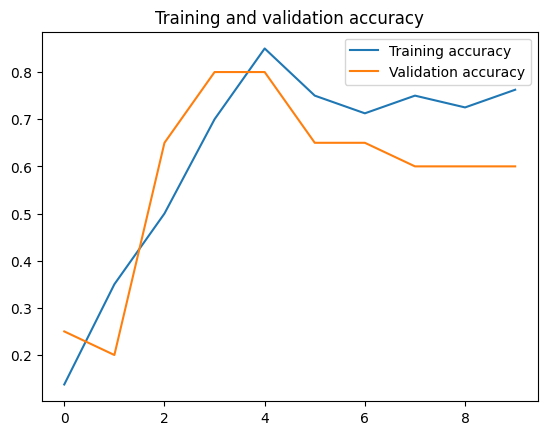

In [ ]:
plt.plot(history.history["accuracy"]+history_fine.history["accuracy"],label="Training accuracy")
plt.plot(history.history["val_accuracy"]+history_fine.history["val_accuracy"],label="Validation accuracy")
plt.legend()
plt.title("Training and validation accuracy")
plt.show()